# 特征提取实验 — Iris 数据集

**目标数据集：** [Iris (鸢尾花)](https://scikit-learn.org/stable/datasets/toy_dataset.html#iris-dataset)
**核心任务：** 将 4 维特征空间映射到 2 维新空间，用更少的维度保留尽可能多的信息

**实验流程：**

| 步骤 | 内容 | 掌握技能 |
|------|------|----------|
| 1 | 环境验证 | Python / scikit-learn / matplotlib / pandas |
| 2 | 数据集回顾 | Iris 基本统计 / 特征选择 vs 特征提取 |
| 3 | 特征提取概述 | 降维动机 / 选择 vs 提取的本质区别 |
| 4 | PCA 原理与实践 | 协方差矩阵 / 特征值分解 / 方差解释比 |
| 5 | LDA 原理与实践 | Fisher 准则 / 类间-类内散度矩阵 |
| 6 | PCA vs LDA 对比 | 无监督 vs 有监督 / 投影方向可视化 |
| 7 | 分类性能对比 | KNN + 交叉验证 / 多方案准确率与耗时比较 |
| 8 | 总结 | 方法对比 / 核心知识点 / 思考题 |

---
## 1. 环境验证

在开始之前，确认所需的工具和库已正确安装：

| 工具/库 | 用途 |
|---------|------|
| **Python 3.11+** | 编程语言 |
| **scikit-learn** | 机器学习库：PCA、LDA、分类器、交叉验证 |
| **matplotlib** | 绑图库：散点图、柱状图 |
| **numpy** | 数值计算：矩阵运算、特征值分解 |
| **pandas** | 数据分析：DataFrame 操作、统计描述 |

In [1]:
import sys
print(f"Python: {sys.version}")

import numpy as np
print(f"numpy: {np.__version__}")

import sklearn
print(f"scikit-learn: {sklearn.__version__}")

import matplotlib
print(f"matplotlib: {matplotlib.__version__}")

import pandas as pd
print(f"pandas: {pd.__version__}")

print("\n环境就绪 ✓")

Python: 3.11.14 (main, Dec 17 2025, 21:07:37) [Clang 21.1.4 ]
numpy: 2.4.2
scikit-learn: 1.8.0
matplotlib: 3.10.8
pandas: 3.0.1

环境就绪 ✓


---
## 2. 数据集回顾

### 2.1 Iris 数据集概览

本实验继续使用 Iris 数据集。如果你已完成实验 2（特征选择），这里是简要回顾：

| 属性 | 值 |
|------|----|
| 样本数 | 150 |
| 特征数 | 4（均为连续值，单位 cm） |
| 类别数 | 3（各 50 个样本） |

| 编号 | 特征名 | 含义 |
|------|--------|------|
| 0 | sepal length | 花萼长度 |
| 1 | sepal width | 花萼宽度 |
| 2 | petal length | 花瓣长度 |
| 3 | petal width | 花瓣宽度 |

| 标签 | 类名 | 中文 |
|------|------|------|
| 0 | setosa | 山鸢尾 |
| 1 | versicolor | 变色鸢尾 |
| 2 | virginica | 维吉尼亚鸢尾 |

In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names

df = pd.DataFrame(X, columns=feature_names)
df["species"] = pd.Categorical.from_codes(y, iris.target_names)

print(f"样本数: {len(df)}, 特征数: {len(feature_names)}, 类别: {list(iris.target_names)}")
print()
df.describe()

样本数: 150, 特征数: 4, 类别: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


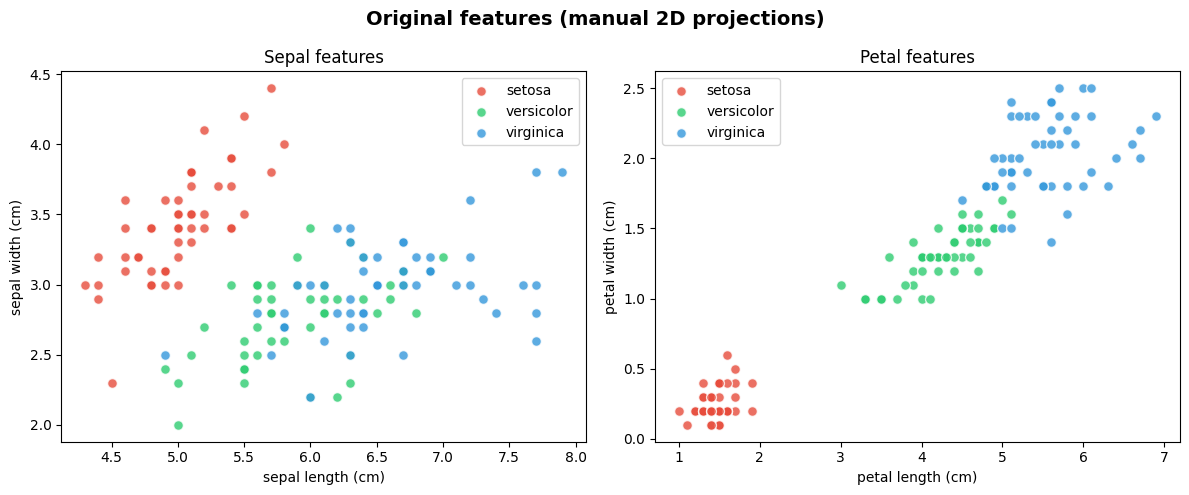

问题：4 维数据有 C(4,2) = 6 种两两组合，哪对最好？能否自动找到最优的 2D 投影？
→ 这正是特征提取要解决的问题。


In [3]:
import matplotlib.pyplot as plt

COLORS = ["#e74c3c", "#2ecc71", "#3498db"]
LABELS = list(iris.target_names)

# 原始 4D 数据 — 任取两对特征投影到 2D
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

pairs = [(0, 1, "Sepal features"), (2, 3, "Petal features")]
for ax, (i, j, title) in zip(axes, pairs):
    for c, name in enumerate(LABELS):
        mask = y == c
        ax.scatter(X[mask, i], X[mask, j],
                   c=COLORS[c], label=name, edgecolors="w", s=50, alpha=0.8)
    ax.set_xlabel(feature_names[i])
    ax.set_ylabel(feature_names[j])
    ax.set_title(title)
    ax.legend()

fig.suptitle("Original features (manual 2D projections)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("问题：4 维数据有 C(4,2) = 6 种两两组合，哪对最好？能否自动找到最优的 2D 投影？")
print("→ 这正是特征提取要解决的问题。")

---
## 3. 特征提取概述

### 3.1 特征选择 vs 特征提取

上一个实验（实验 2）学习了**特征选择**——从原始特征中挑选子集。本实验学习**特征提取**——通过数学变换创造全新的特征。

```
特征选择 (Feature Selection)          特征提取 (Feature Extraction)
──────────────────────────          ──────────────────────────────

原始 4 维特征                         原始 4 维特征
┌────┬────┬────┬────┐              ┌────┬────┬────┬────┐
│ f0 │ f1 │ f2 │ f3 │              │ f0 │ f1 │ f2 │ f3 │
└────┴────┴────┴────┘              └──┬─┴──┬─┴──┬─┴──┬─┘
      │         │                     │    │    │    │
      │ 挑选子集 │                     └────┴────┴────┘
      ▼         ▼                         │ 线性组合
   ┌────┬────┐                            ▼
   │ f1 │ f3 │  ← 原始特征           ┌─────┬─────┐
   └────┴────┘                        │ PC1 │ PC2 │  ← 全新特征
                                      └─────┴─────┘
                                      PC1 = w11*f0 + w12*f1 + w13*f2 + w14*f3
                                      PC2 = w21*f0 + w22*f1 + w23*f2 + w24*f3
```

### 核心区别

| 维度 | 特征选择 | 特征提取 |
|------|----------|----------|
| **操作** | 从原始特征中 **挑选** 子集 | 将原始特征 **变换** 为新特征 |
| **新特征含义** | 仍是原始物理量（如花瓣长度） | 是原始特征的线性组合（无直接物理含义） |
| **可解释性** | 高（知道保留了哪些特征） | 较低（新特征是抽象的主成分或判别分量） |
| **信息利用** | 丢弃未选特征的全部信息 | 综合利用所有原始特征的信息 |
| **代表方法** | ANOVA, SFS, SFFS, Lasso | PCA, LDA, t-SNE, 自编码器 |

### 3.2 为什么需要特征提取？

1. **降维（Dimensionality Reduction）** — 高维数据难以可视化、计算量大、容易过拟合
2. **去相关（Decorrelation）** — 原始特征可能高度相关，提取后的新特征互不相关
3. **噪声过滤** — 低方差方向通常对应噪声，提取时可以舍弃
4. **增强区分度** — LDA 等有监督方法可以找到最优分类投影方向

### 3.3 本实验的两种方法

| 方法 | 全称 | 类型 | 优化目标 |
|------|------|------|----------|
| **PCA** | Principal Component Analysis (主成分分析) | **无监督** | 最大化投影后的方差 |
| **LDA** | Linear Discriminant Analysis (线性判别分析) | **有监督** | 最大化类间距 / 最小化类内距 |

> **关键直觉：** PCA 找的是数据散得最开的方向（不看标签），LDA 找的是各类分得最开的方向（利用标签）。

---
## 4. PCA — 主成分分析

### 4.1 核心思想

PCA 的目标：找到一组新的坐标轴（主成分），使数据在新轴上的**方差最大化**。

**为什么最大化方差？** 方差大 = 信息多。如果所有样本在某个方向上的投影几乎相同（方差 ≈ 0），那这个方向没有提供有用信息，可以丢弃。

```
原始 2D 数据                          PCA 找到的新坐标轴
─────────────                        ──────────────────

  y│    * *                             PC1 (第一主成分)
   │   * * *                             ╱
   │  * * * *                           ╱  * *
   │ * * * *                           ╱  * * *          PC2
   │  * * *                           ╱  * * * *        ╱
   │   * *                           ╱  * * * *        ╱
   └──────── x                      ╱  * * *          ╱
                                   ╱  * *            ╱
                                  ╱                 ╱
                                 ╱  ← 方差最大方向

  数据沿斜方向展开               PC1 捕获了最大方差（主要信息）
  x 和 y 轴都不是最优             PC2 捕获剩余方差（次要信息）
```

### 4.2 数学原理

#### Step 1：数据中心化

将每个特征减去其均值，使数据以原点为中心：

$$\bar{X} = X - \mu$$

其中 $\mu$ 是每个特征的均值向量。

> **为什么要中心化？** PCA 基于方差和协方差计算，中心化确保方差的计算不受均值偏移影响。

#### Step 2：计算协方差矩阵

$$C = \frac{1}{n-1} \bar{X}^T \bar{X}$$

协方差矩阵 $C$ 是一个 $d \times d$ 矩阵（$d$ = 特征数），描述了特征之间的线性相关性：

```
         sepal_L   sepal_W   petal_L   petal_W
sepal_L [  var00    cov01    cov02    cov03  ]
sepal_W [  cov10    var11    cov12    cov13  ]
petal_L [  cov20    cov21    var22    cov23  ]
petal_W [  cov30    cov31    cov32    var33  ]

对角线 = 各特征的方差
非对角线 = 特征对之间的协方差
  协方差 > 0 → 正相关
  协方差 < 0 → 负相关
  协方差 ≈ 0 → 不相关
```

#### Step 3：特征值分解

对协方差矩阵做特征值分解（Eigendecomposition）：

$$C \, \mathbf{v}_i = \lambda_i \, \mathbf{v}_i$$

- $\lambda_i$ = 第 $i$ 个**特征值**（eigenvalue）→ 表示对应主成分方向上的方差大小
- $\mathbf{v}_i$ = 第 $i$ 个**特征向量**（eigenvector）→ 表示对应主成分的方向

#### Step 4：选择前 k 个主成分

按特征值从大到小排序，取前 $k$ 个特征向量组成投影矩阵 $W$：

$$W = [\mathbf{v}_1, \mathbf{v}_2, \dots, \mathbf{v}_k] \quad (d \times k)$$

#### Step 5：投影

$$X_{\text{new}} = \bar{X} \cdot W \quad (n \times k)$$

### 4.3 PCA 算法步骤总结

```
输入: X (n*d), 目标维度 k

1. 中心化      X_bar = X - mean(X)
                    │
                    ▼
2. 协方差矩阵   C = X_bar.T @ X_bar / (n-1)     → d*d 矩阵
                    │
                    ▼
3. 特征值分解   C @ vi = lambda_i * vi           → d 个 (lambda, v) 对
                    │
                    ▼
4. 排序 + 选择  lambda1 >= lambda2 >= ... >= lambdad   → 取前 k 个 v
                    │
                    ▼
5. 投影         X_new = X_bar @ W                → n*k 矩阵

输出: X_new (n*k), 降维后的数据
```

### 4.4 手动实现 PCA

为了加深理解，我们先用 NumPy 从零实现 PCA 的每一步，再和 scikit-learn 的结果对比。

In [4]:
# ===== 手动 PCA：逐步实现 =====

# Step 1: 中心化
X_mean = X.mean(axis=0)
X_centered = X - X_mean

print("Step 1: 中心化")
print(f"  各特征均值: {X_mean}")
print(f"  中心化后均值 (应接近 0): {X_centered.mean(axis=0).round(15)}")

Step 1: 中心化
  各特征均值: [5.84333333 3.05733333 3.758      1.19933333]
  中心化后均值 (应接近 0): [-1.e-15 -1.e-15 -3.e-15 -0.e+00]


In [5]:
# Step 2: 计算协方差矩阵
cov_matrix = np.cov(X_centered, rowvar=False)  # rowvar=False: 每列是一个特征

print("Step 2: 协方差矩阵 (4x4)")
cov_df = pd.DataFrame(cov_matrix,
                      index=[n.split(" (")[0] for n in feature_names],
                      columns=[n.split(" (")[0] for n in feature_names])
print(cov_df.round(4).to_string())

print("\n观察:")
print("  - petal length 方差最大 (3.1163) → 信息量最多")
print("  - petal length 与 petal width 协方差大 (1.2956) → 高度正相关")
print("  - sepal width 与其他特征协方差小甚至为负 → 相关性弱")

Step 2: 协方差矩阵 (4x4)
              sepal length  sepal width  petal length  petal width
sepal length        0.6857      -0.0424        1.2743       0.5163
sepal width        -0.0424       0.1900       -0.3297      -0.1216
petal length        1.2743      -0.3297        3.1163       1.2956
petal width         0.5163      -0.1216        1.2956       0.5810

观察:
  - petal length 方差最大 (3.1163) → 信息量最多
  - petal length 与 petal width 协方差大 (1.2956) → 高度正相关
  - sepal width 与其他特征协方差小甚至为负 → 相关性弱


In [6]:
# Step 3: 特征值分解
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# eigh 返回升序排列，我们需要降序
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("Step 3: 特征值分解")
print(f"  特征值 (降序): {eigenvalues.round(4)}")
print(f"  方差解释比:    {(eigenvalues / eigenvalues.sum() * 100).round(2)}%")
print()
print("特征向量 (每列是一个主成分方向):")
ev_df = pd.DataFrame(eigenvectors,
                     index=[n.split(" (")[0] for n in feature_names],
                     columns=[f"PC{i+1}" for i in range(4)])
print(ev_df.round(4).to_string())

print("\n解读 PC1 的特征向量:")
print("  PC1 ≈ 0.36*sepal_L - 0.08*sepal_W + 0.86*petal_L + 0.36*petal_W")
print("  → PC1 主要由 petal length 主导 (权重 0.86 最大)")

Step 3: 特征值分解
  特征值 (降序): [4.2282 0.2427 0.0782 0.0238]
  方差解释比:    [92.46  5.31  1.71  0.52]%

特征向量 (每列是一个主成分方向):
                 PC1     PC2     PC3     PC4
sepal length -0.3614  0.6566  0.5820  0.3155
sepal width   0.0845  0.7302 -0.5979 -0.3197
petal length -0.8567 -0.1734 -0.0762 -0.4798
petal width  -0.3583 -0.0755 -0.5458  0.7537

解读 PC1 的特征向量:
  PC1 ≈ 0.36*sepal_L - 0.08*sepal_W + 0.86*petal_L + 0.36*petal_W
  → PC1 主要由 petal length 主导 (权重 0.86 最大)


In [7]:
# Step 4 & 5: 选前 2 个主成分，投影
k = 2
W_manual = eigenvectors[:, :k]  # 投影矩阵 (4x2)
X_pca_manual = X_centered @ W_manual  # 投影 (150x2)

print(f"Step 4-5: 投影到 {k} 维")
print(f"  投影矩阵 W 形状: {W_manual.shape}")
print(f"  投影后数据形状: {X_pca_manual.shape}")
print(f"  前 5 个样本:")
print(pd.DataFrame(X_pca_manual[:5], columns=["PC1", "PC2"]).to_string(index=False))

Step 4-5: 投影到 2 维
  投影矩阵 W 形状: (4, 2)
  投影后数据形状: (150, 2)
  前 5 个样本:
     PC1       PC2
2.684126  0.319397
2.714142 -0.177001
2.888991 -0.144949
2.745343 -0.318299
2.728717  0.326755


### 4.5 用 scikit-learn 验证

scikit-learn 的 `PCA` 类封装了上述所有步骤，一行代码即可完成。我们用它来验证手动实现的结果。

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca_sklearn = pca.fit_transform(X)

print("=== scikit-learn PCA 结果 ===")
print(f"解释方差比: {pca.explained_variance_ratio_.round(4)}")
print(f"累计解释方差: {pca.explained_variance_ratio_.sum():.4f} ({pca.explained_variance_ratio_.sum()*100:.2f}%)")
print()

# 验证手动实现与 sklearn 结果一致
# 注意：特征向量可能有符号差异 (v 和 -v 都是合法的特征向量)
# 所以我们比较绝对值
diff = np.abs(np.abs(X_pca_manual) - np.abs(X_pca_sklearn)).max()
print(f"手动实现 vs sklearn 最大差异: {diff:.2e}")
print("→ 差异极小，验证通过 ✓")

=== scikit-learn PCA 结果 ===
解释方差比: [0.9246 0.0531]
累计解释方差: 0.9777 (97.77%)

手动实现 vs sklearn 最大差异: 3.61e-14
→ 差异极小，验证通过 ✓


### 4.6 PCA 2D 散点图

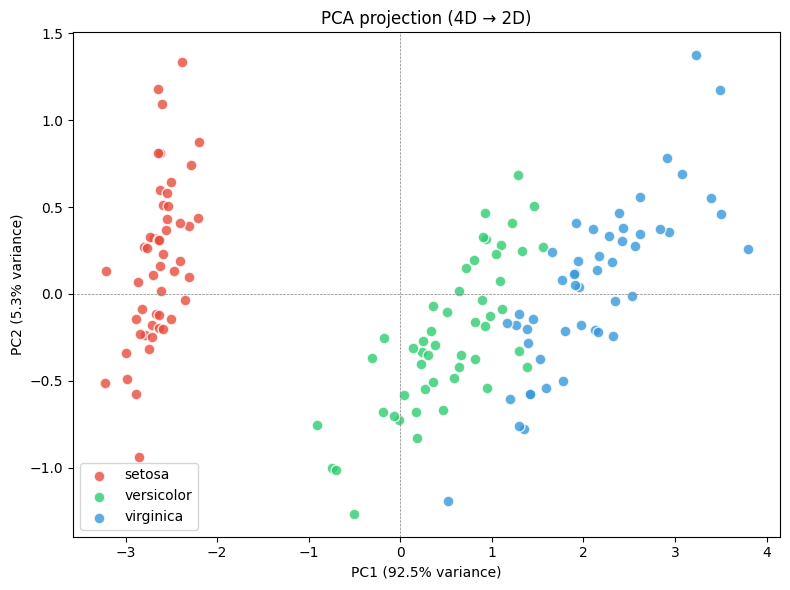

观察:
  - setosa 与其他两类在 PC1 方向上完全分离
  - versicolor 和 virginica 在 PC1 上有部分重叠，但 PC2 提供了额外区分
  - 仅用 2 个主成分就保留了约 97.8% 的总方差


In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

for i, name in enumerate(LABELS):
    mask = y == i
    ax.scatter(X_pca_sklearn[mask, 0], X_pca_sklearn[mask, 1],
               c=COLORS[i], label=name, edgecolors="w", s=60, alpha=0.8)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("PCA projection (4D → 2D)")
ax.legend()
ax.axhline(y=0, color="gray", linewidth=0.5, linestyle="--")
ax.axvline(x=0, color="gray", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()

print("观察:")
print("  - setosa 与其他两类在 PC1 方向上完全分离")
print("  - versicolor 和 virginica 在 PC1 上有部分重叠，但 PC2 提供了额外区分")
print("  - 仅用 2 个主成分就保留了约 97.8% 的总方差")

### 4.7 方差解释比（Explained Variance Ratio）

方差解释比表示每个主成分捕获了多少比例的总方差。它是选择主成分个数 $k$ 的重要依据：

$$\text{EVR}_i = \frac{\lambda_i}{\sum_{j=1}^{d} \lambda_j}$$

**选择 $k$ 的常用准则：**
- **累计解释方差 >= 85%~95%** — 保留足够多的信息
- **肘部法则（Elbow method）** — 在解释方差曲线的拐点处截断
- **Kaiser 准则** — 只保留特征值 > 1 的主成分（适用于标准化数据）

=== 各主成分方差解释比 ===
主成分    特征值  方差解释比   累计解释比
PC1 4.2282 92.46%  92.46%
PC2 0.2427  5.31%  97.77%
PC3 0.0782  1.71%  99.48%
PC4 0.0238  0.52% 100.00%


/tmp/ipykernel_3363359/2714802878.py:40: UserWarning: Glyph 32047 (\N{CJK UNIFIED IDEOGRAPH-7D2F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3363359/2714802878.py:40: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3363359/2714802878.py:40: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3363359/2714802878.py:40: UserWarning: Glyph 37322 (\N{CJK UNIFIED IDEOGRAPH-91CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3363359/2714802878.py:40: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3363359/2714802878.py:40: UserWarning: Glyph 38408 (\N{CJK UNIFIED IDEOGRAPH-9608}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3363359/2714802878.py:40: UserWarning: Glyph 20540 (\N{CJK UN

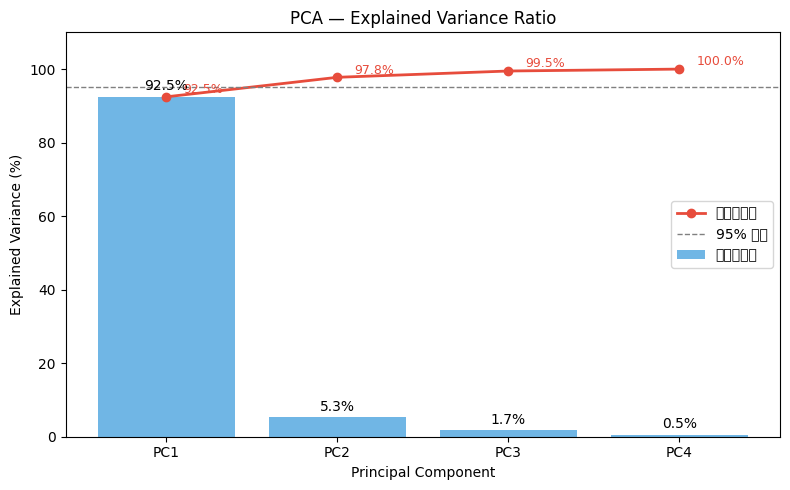

结论:
  - PC1 单独就解释了 92.5% 的方差
  - PC1 + PC2 累计 97.8% → 保留 2 个主成分即可
  - PC3 + PC4 合计仅 2.2% → 几乎不包含有用信息


In [10]:
# 全部 4 个主成分的方差解释比
pca_full = PCA(n_components=4)
pca_full.fit(X)

evr = pca_full.explained_variance_ratio_
cumulative_evr = np.cumsum(evr)

# 表格
evr_df = pd.DataFrame({
    "主成分": [f"PC{i+1}" for i in range(4)],
    "特征值": pca_full.explained_variance_.round(4),
    "方差解释比": [f"{v*100:.2f}%" for v in evr],
    "累计解释比": [f"{v*100:.2f}%" for v in cumulative_evr],
})
print("=== 各主成分方差解释比 ===")
print(evr_df.to_string(index=False))

# 可视化
fig, ax = plt.subplots(figsize=(8, 5))
x_pos = np.arange(1, 5)

bars = ax.bar(x_pos, evr * 100, color="#3498db", alpha=0.7, label="单个解释比")
ax.plot(x_pos, cumulative_evr * 100, "o-", color="#e74c3c", linewidth=2, label="累计解释比")
ax.axhline(y=95, color="gray", linewidth=1, linestyle="--", label="95% 阈值")

for bar, val in zip(bars, evr * 100):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=10)

for i, val in enumerate(cumulative_evr * 100):
    ax.text(x_pos[i] + 0.1, val + 1, f"{val:.1f}%", fontsize=9, color="#e74c3c")

ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance (%)")
ax.set_title("PCA — Explained Variance Ratio")
ax.set_xticks(x_pos)
ax.set_xticklabels([f"PC{i}" for i in x_pos])
ax.set_ylim(0, 110)
ax.legend()
plt.tight_layout()
plt.show()

print("结论:")
print(f"  - PC1 单独就解释了 {evr[0]*100:.1f}% 的方差")
print(f"  - PC1 + PC2 累计 {cumulative_evr[1]*100:.1f}% → 保留 2 个主成分即可")
print(f"  - PC3 + PC4 合计仅 {(1 - cumulative_evr[1])*100:.1f}% → 几乎不包含有用信息")

### 4.8 PCA 载荷图（Loading Plot）

载荷图展示了**原始特征**与**主成分**之间的关系。每个箭头表示一个原始特征在 PC1-PC2 空间中的投影方向和贡献强度。

- 箭头越长 → 该特征对主成分的贡献越大
- 箭头方向 → 该特征在主成分空间中的朝向
- 两个箭头夹角小 → 两个特征高度相关

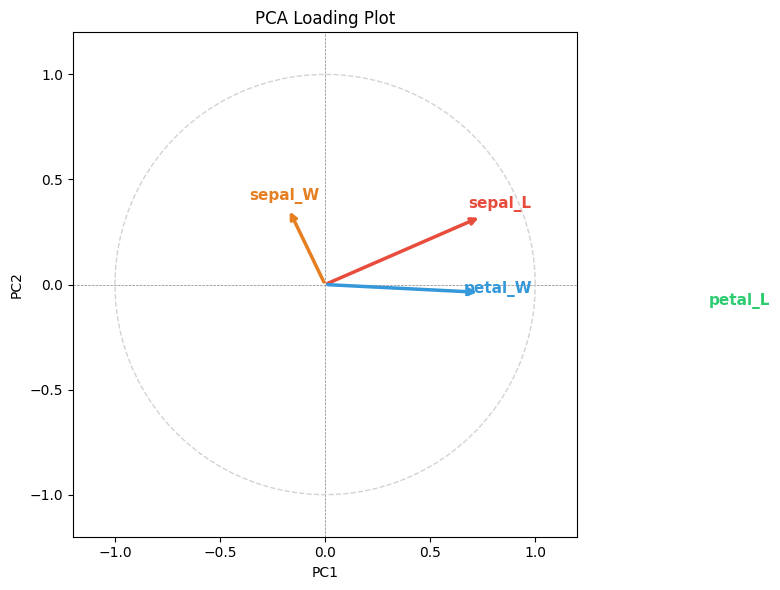

解读:
  - petal_L 和 petal_W 箭头方向几乎一致 → 高度正相关
  - sepal_L 也指向 PC1 正方向 → 与花瓣特征正相关
  - sepal_W 指向 PC2 正方向 → 与其他特征相关性弱，主要贡献 PC2


In [11]:
fig, ax = plt.subplots(figsize=(7, 6))

# 载荷 = 特征向量 * sqrt(特征值)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

arrow_colors = ["#e74c3c", "#e67e22", "#2ecc71", "#3498db"]
short_names = ["sepal_L", "sepal_W", "petal_L", "petal_W"]

for i, (name, color) in enumerate(zip(short_names, arrow_colors)):
    ax.annotate("", xy=(loadings[i, 0], loadings[i, 1]), xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color=color, lw=2.5))
    ax.text(loadings[i, 0] * 1.12, loadings[i, 1] * 1.12, name,
            fontsize=11, fontweight="bold", color=color, ha="center")

ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA Loading Plot")
ax.axhline(y=0, color="gray", linewidth=0.5, linestyle="--")
ax.axvline(x=0, color="gray", linewidth=0.5, linestyle="--")
ax.set_aspect("equal")

# 画单位圆参考
theta = np.linspace(0, 2 * np.pi, 100)
ax.plot(np.cos(theta), np.sin(theta), "--", color="lightgray", linewidth=1)

plt.tight_layout()
plt.show()

print("解读:")
print("  - petal_L 和 petal_W 箭头方向几乎一致 → 高度正相关")
print("  - sepal_L 也指向 PC1 正方向 → 与花瓣特征正相关")
print("  - sepal_W 指向 PC2 正方向 → 与其他特征相关性弱，主要贡献 PC2")

### 4.9 标准化对 PCA 的影响

PCA 基于方差计算，所以**特征的量纲（尺度）会影响结果**。

```
特征 A: 收入 (元)      范围 3000 ~ 50000    方差 ≈ 10^8
特征 B: 年龄 (岁)      范围 18 ~ 65         方差 ≈ 200

不标准化 → PCA 几乎只看特征 A (因为方差碾压 B)
标准化后 → 两个特征被拉平到同一尺度，公平对待
```

**标准化（Standardization）：** 将每个特征变换为均值 0、标准差 1：

$$z = \frac{x - \mu}{\sigma}$$

> **Iris 的情况：** 4 个特征都是 cm，量纲相同，尺度差异不大，所以不标准化也可以。但为了展示良好实践，我们对比一下标准化前后的结果。

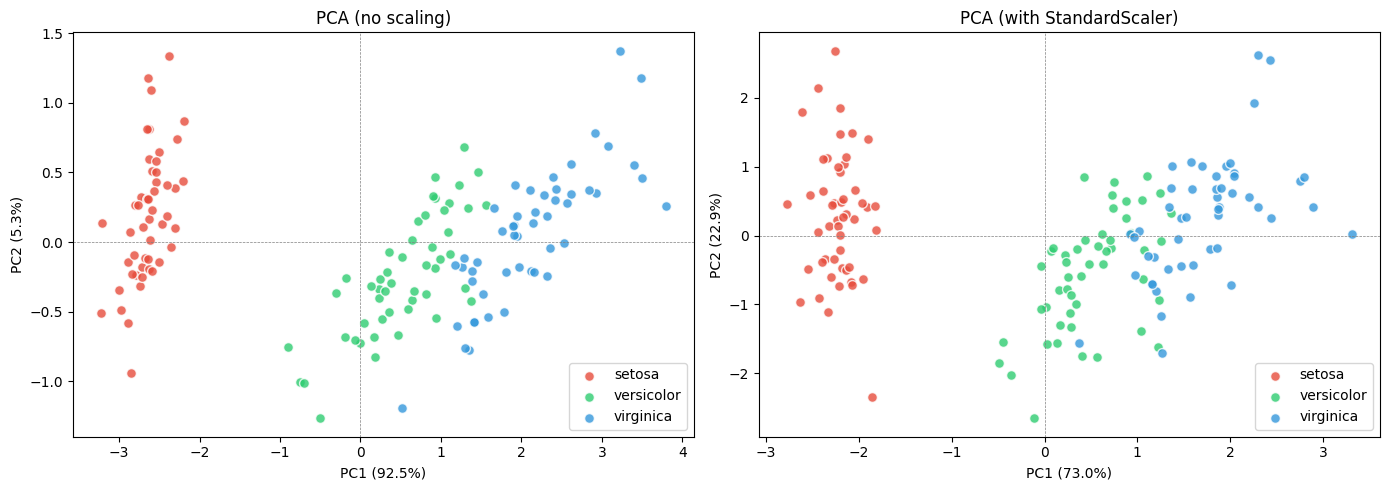

对比:
  未标准化 — PC1: 92.5%, PC2: 5.3%
  标准化后 — PC1: 73.0%, PC2: 22.9%

  Iris 特征尺度相近，所以标准化前后差异不大。
  但当特征量纲不同时（如身高 cm + 体重 kg + 收入 元），标准化是必须的。


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_scaled = PCA(n_components=2)
X_pca_scaled = pca_scaled.fit_transform(X_scaled)

# 对比
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title, ev in [
    (axes[0], X_pca_sklearn, "PCA (no scaling)", pca.explained_variance_ratio_),
    (axes[1], X_pca_scaled, "PCA (with StandardScaler)", pca_scaled.explained_variance_ratio_),
]:
    for i, name in enumerate(LABELS):
        mask = y == i
        ax.scatter(data[mask, 0], data[mask, 1],
                   c=COLORS[i], label=name, edgecolors="w", s=50, alpha=0.8)
    ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}%)")
    ax.set_title(title)
    ax.legend()
    ax.axhline(y=0, color="gray", linewidth=0.5, linestyle="--")
    ax.axvline(x=0, color="gray", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.show()

print("对比:")
print(f"  未标准化 — PC1: {pca.explained_variance_ratio_[0]*100:.1f}%, PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"  标准化后 — PC1: {pca_scaled.explained_variance_ratio_[0]*100:.1f}%, PC2: {pca_scaled.explained_variance_ratio_[1]*100:.1f}%")
print("\n  Iris 特征尺度相近，所以标准化前后差异不大。")
print("  但当特征量纲不同时（如身高 cm + 体重 kg + 收入 元），标准化是必须的。")

### 4.10 PCA 小结

| 要点 | 说明 |
|------|------|
| 类型 | **无监督** — 不使用类别标签 |
| 目标 | 最大化投影后的方差（保留最多信息） |
| 核心步骤 | 中心化 → 协方差矩阵 → 特征值分解 → 投影 |
| 主成分数选择 | 累计方差解释比 >= 95% 或肘部法则 |
| 标准化 | 特征量纲不同时必须先标准化 |
| 优点 | 无需标签、去相关、降噪 |
| 局限 | 只捕获线性关系、不保证类别可分 |

---
## 5. LDA — 线性判别分析

### 5.1 核心思想

PCA 的目标是方差最大化，但方差大不等于分类好。LDA 直接以**分类**为目标，寻找使**类间距最大、类内距最小**的投影方向。

```
PCA 的视角 (无监督)                   LDA 的视角 (有监督)
──────────────────                   ──────────────────

  哪个方向数据散得最开？                哪个方向各类分得最开？

     o o                                * *
   o o o o     ← PCA 可能              * * *     ← LDA 寻找
   * * * *       选这个方向            o o o        这个方向
     * *          (方差大               o o          (类间距大
                   但类重叠)                           类内距小)
```

### 5.2 Fisher 判别准则

LDA 使用 **Fisher 准则** 来衡量投影方向的好坏：

$$J(\mathbf{w}) = \frac{\mathbf{w}^T S_B \mathbf{w}}{\mathbf{w}^T S_W \mathbf{w}}$$

- $S_B$ = **类间散度矩阵**（Between-class Scatter）— 类别中心之间的距离
- $S_W$ = **类内散度矩阵**（Within-class Scatter）— 各类别内部的离散程度
- $J(\mathbf{w})$ 越大 → 类间距大且类内距小 → 投影方向越好

> **直觉：** Fisher 准则就是一个信噪比——信号是类间差异（$S_B$），噪声是类内波动（$S_W$）。最优方向使信噪比最大。

### 5.3 散度矩阵的定义

```
类内散度矩阵 Sw:
─────────────────

  Sw = sum_k  sum_{x in Ck}  (x - mu_k)(x - mu_k).T

  mu_k = 第 k 类的均值向量
  Ck   = 第 k 类的样本集合

  → 衡量每个类内部样本到其均值的离散程度
  → Sw 越小 → 各类内部越紧凑 → 越好


类间散度矩阵 Sb:
─────────────────

  Sb = sum_k  nk * (mu_k - mu)(mu_k - mu).T

  mu = 全体样本的均值向量
  nk = 第 k 类的样本数

  → 衡量各类中心到全局中心的距离
  → Sb 越大 → 各类之间距离越远 → 越好
```

### 5.4 LDA 求解

最大化 Fisher 准则等价于求解广义特征值问题：

$$S_B \mathbf{v} = \lambda \, S_W \mathbf{v}$$

即：$S_W^{-1} S_B \mathbf{v} = \lambda \mathbf{v}$

取前 $k$ 个最大特征值对应的特征向量，组成投影矩阵。

**LDA 的维度限制：** 对于 $K$ 个类别，LDA 最多产生 $K-1$ 个判别分量。

| 类别数 K | 最大 LDA 维度 |
|----------|---------------|
| 2 | 1 维 |
| 3 | 2 维 |
| 10 | 9 维 |

> Iris 有 3 个类别，所以 LDA 最多投影到 **2 维**。

### 5.5 LDA 算法步骤

```
输入: X (n*d), y (类别标签), 目标维度 k (<= K-1)

1. 计算各类均值 mu_k 和全局均值 mu
                    │
                    ▼
2. 计算 Sw = sum sum (x-mu_k)(x-mu_k).T     → 类内散度 (d*d)
   计算 Sb = sum nk*(mu_k-mu)(mu_k-mu).T     → 类间散度 (d*d)
                    │
                    ▼
3. 求解 Sw^(-1) @ Sb @ v = lambda * v        → 广义特征值问题
                    │
                    ▼
4. 取前 k 个特征向量 → W (d*k)
                    │
                    ▼
5. 投影: X_new = X @ W                       → n*k

输出: X_new (n*k), 降维后的数据
```

### 5.6 手动实现 LDA

In [13]:
# ===== 手动 LDA：逐步实现 =====

n_classes = len(np.unique(y))
n_features = X.shape[1]

# Step 1: 各类均值和全局均值
mean_overall = X.mean(axis=0)
mean_vectors = []
for c in range(n_classes):
    mean_vectors.append(X[y == c].mean(axis=0))

print("Step 1: 计算均值向量")
print(f"  全局均值: {mean_overall.round(3)}")
for c, mv in enumerate(mean_vectors):
    print(f"  类 {c} ({iris.target_names[c]:12s}) 均值: {mv.round(3)}")

Step 1: 计算均值向量
  全局均值: [5.843 3.057 3.758 1.199]
  类 0 (setosa      ) 均值: [5.006 3.428 1.462 0.246]
  类 1 (versicolor  ) 均值: [5.936 2.77  4.26  1.326]
  类 2 (virginica   ) 均值: [6.588 2.974 5.552 2.026]


In [14]:
# Step 2: 计算类内散度矩阵 Sw 和类间散度矩阵 Sb
Sw = np.zeros((n_features, n_features))
for c in range(n_classes):
    X_c = X[y == c]
    diff = X_c - mean_vectors[c]  # (nk x d)
    Sw += diff.T @ diff           # (d x d)

Sb = np.zeros((n_features, n_features))
for c in range(n_classes):
    n_c = np.sum(y == c)
    diff = (mean_vectors[c] - mean_overall).reshape(-1, 1)  # (d x 1)
    Sb += n_c * (diff @ diff.T)                              # (d x d)

print("Step 2: 散度矩阵")
short = [n.split(" (")[0] for n in feature_names]
print("\n  类内散度矩阵 Sw:")
print(pd.DataFrame(Sw, index=short, columns=short).round(3).to_string())
print("\n  类间散度矩阵 Sb:")
print(pd.DataFrame(Sb, index=short, columns=short).round(3).to_string())

Step 2: 散度矩阵

  类内散度矩阵 Sw:
              sepal length  sepal width  petal length  petal width
sepal length        38.956       13.630        24.625        5.645
sepal width         13.630       16.962         8.121        4.808
petal length        24.625        8.121        27.223        6.272
petal width          5.645        4.808         6.272        6.157

  类间散度矩阵 Sb:
              sepal length  sepal width  petal length  petal width
sepal length        63.212      -19.953       165.248       71.279
sepal width        -19.953       11.345       -57.240      -22.933
petal length       165.248      -57.240       437.103      186.774
petal width         71.279      -22.933       186.774       80.413


In [15]:
# Step 3: 求解广义特征值问题 Sw^(-1) @ Sb @ v = lambda * v
Sw_inv_Sb = np.linalg.inv(Sw) @ Sb
eigenvalues_lda, eigenvectors_lda = np.linalg.eig(Sw_inv_Sb)

# 取实部（数值误差可能导致微小虚部）
eigenvalues_lda = eigenvalues_lda.real
eigenvectors_lda = eigenvectors_lda.real

# 降序排列
idx = np.argsort(eigenvalues_lda)[::-1]
eigenvalues_lda = eigenvalues_lda[idx]
eigenvectors_lda = eigenvectors_lda[:, idx]

print("Step 3: 广义特征值分解")
print(f"  特征值: {eigenvalues_lda.round(4)}")
# LDA 最多 K-1 个有意义的分量
total = eigenvalues_lda[:n_classes-1].sum()
ratios = eigenvalues_lda[:n_classes-1] / total
print(f"  判别比例 (前 {n_classes-1} 个): {(ratios * 100).round(2)}%")
print()
print("  → 特征值 3 和 4 接近 0，对应的方向无判别能力")
print(f"  → Iris 有 3 个类别，LDA 最多 {n_classes-1} 个有效判别分量")

Step 3: 广义特征值分解
  特征值: [32.1919  0.2854 -0.     -0.    ]
  判别比例 (前 2 个): [99.12  0.88]%

  → 特征值 3 和 4 接近 0，对应的方向无判别能力
  → Iris 有 3 个类别，LDA 最多 2 个有效判别分量


In [16]:
# Step 4 & 5: 投影到 2D
W_lda_manual = eigenvectors_lda[:, :2]  # (4x2)
X_lda_manual = X @ W_lda_manual  # (150x2)

print(f"Step 4-5: 投影到 2 维")
print(f"  投影矩阵 W 形状: {W_lda_manual.shape}")
print(f"  投影后数据形状: {X_lda_manual.shape}")

Step 4-5: 投影到 2 维
  投影矩阵 W 形状: (4, 2)
  投影后数据形状: (150, 2)


### 5.7 用 scikit-learn 实现 LDA

In [17]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=2)
X_lda_sklearn = lda.fit_transform(X, y)

print("=== scikit-learn LDA 结果 ===")
print(f"判别分量解释比: {lda.explained_variance_ratio_.round(4)}")
print(f"LD1 解释: {lda.explained_variance_ratio_[0]*100:.2f}%")
print(f"LD2 解释: {lda.explained_variance_ratio_[1]*100:.2f}%")

=== scikit-learn LDA 结果 ===
判别分量解释比: [0.9912 0.0088]
LD1 解释: 99.12%
LD2 解释: 0.88%


### 5.8 LDA 2D 散点图

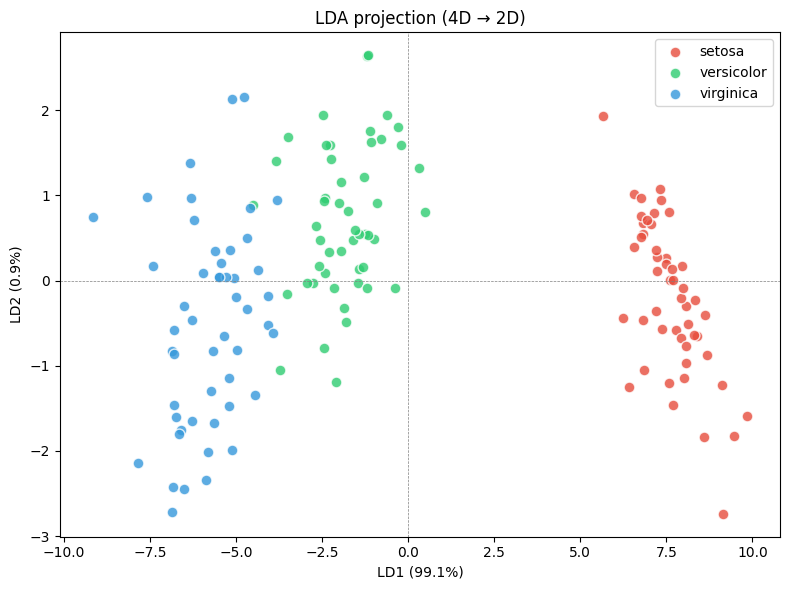

观察:
  - 三个类别在 LD1 方向上几乎完全分离
  - setosa 距离其他两类很远
  - versicolor 和 virginica 之间的间隔比 PCA 更清晰
  → LDA 利用标签信息找到了更优的分类投影方向


In [18]:
fig, ax = plt.subplots(figsize=(8, 6))

for i, name in enumerate(LABELS):
    mask = y == i
    ax.scatter(X_lda_sklearn[mask, 0], X_lda_sklearn[mask, 1],
               c=COLORS[i], label=name, edgecolors="w", s=60, alpha=0.8)

ax.set_xlabel(f"LD1 ({lda.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"LD2 ({lda.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("LDA projection (4D → 2D)")
ax.legend()
ax.axhline(y=0, color="gray", linewidth=0.5, linestyle="--")
ax.axvline(x=0, color="gray", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()

print("观察:")
print("  - 三个类别在 LD1 方向上几乎完全分离")
print("  - setosa 距离其他两类很远")
print("  - versicolor 和 virginica 之间的间隔比 PCA 更清晰")
print("  → LDA 利用标签信息找到了更优的分类投影方向")

### 5.9 LDA 小结

| 要点 | 说明 |
|------|------|
| 类型 | **有监督** — 需要类别标签 |
| 目标 | 最大化 Fisher 准则（类间距 / 类内距） |
| 核心步骤 | 计算 Sw, Sb → 广义特征值分解 → 投影 |
| 维度限制 | 最多 K-1 个判别分量（K = 类别数） |
| 优点 | 直接优化分类目标、类别分离效果好 |
| 局限 | 需要标签、假设各类协方差相同（同方差假设） |

---
## 6. PCA vs LDA 对比

### 6.1 投影结果对比

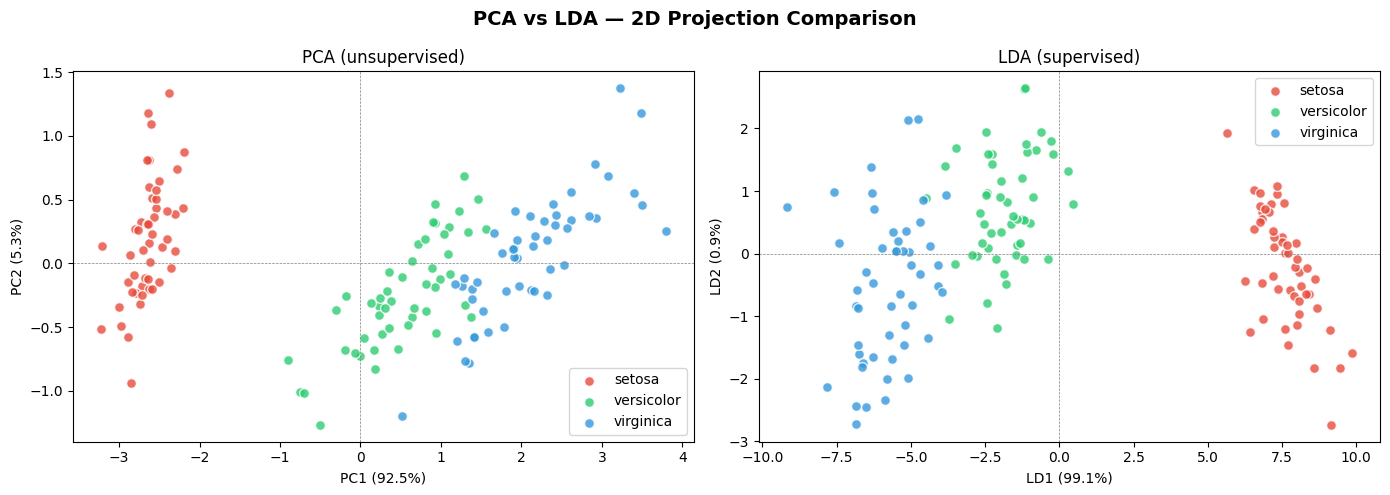

对比:
  PCA (左): 最大化总方差，setosa 分离好，但 versicolor/virginica 有重叠
  LDA (右): 最大化类间区分度，三类分离更清晰

  → 如果目标是分类，LDA 通常比 PCA 更有效
  → 如果没有标签（无监督场景），只能用 PCA


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

datasets = [
    (axes[0], X_pca_sklearn, "PCA (unsupervised)",
     f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)",
     f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"),
    (axes[1], X_lda_sklearn, "LDA (supervised)",
     f"LD1 ({lda.explained_variance_ratio_[0]*100:.1f}%)",
     f"LD2 ({lda.explained_variance_ratio_[1]*100:.1f}%)"),
]

for ax, data, title, xlabel, ylabel in datasets:
    for i, name in enumerate(LABELS):
        mask = y == i
        ax.scatter(data[mask, 0], data[mask, 1],
                   c=COLORS[i], label=name, edgecolors="w", s=50, alpha=0.8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.axhline(y=0, color="gray", linewidth=0.5, linestyle="--")
    ax.axvline(x=0, color="gray", linewidth=0.5, linestyle="--")

fig.suptitle("PCA vs LDA — 2D Projection Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("对比:")
print("  PCA (左): 最大化总方差，setosa 分离好，但 versicolor/virginica 有重叠")
print("  LDA (右): 最大化类间区分度，三类分离更清晰")
print("\n  → 如果目标是分类，LDA 通常比 PCA 更有效")
print("  → 如果没有标签（无监督场景），只能用 PCA")

### 6.2 核心差异总结

```
              PCA                              LDA
              ───                              ───

  输入:    X (数据)                        X (数据) + y (标签)
              │                                  │
              ▼                                  ▼
  优化:   max Var(Xw)                      max  w.T @ Sb @ w
          ───────────                           ──────────────
          最大化方差                         w.T @ Sw @ w
                                            最大化 Fisher 准则
              │                                  │
              ▼                                  ▼
  求解:   C @ v = lambda * v               Sw^(-1) @ Sb @ v = lambda * v
          协方差矩阵特征分解                  广义特征值分解
              │                                  │
              ▼                                  ▼
  维度:   最多 d 个                         最多 K-1 个
          (d = 原始维度)                    (K = 类别数)
```

| 维度 | PCA | LDA |
|------|-----|-----|
| **监督类型** | 无监督 | 有监督 |
| **优化目标** | 最大化方差 | 最大化 Fisher 准则 |
| **矩阵分解** | 协方差矩阵 | Sw^(-1) @ Sb |
| **最大维度** | d (原始维度) | K-1 (类别数-1) |
| **是否需要标签** | 否 | 是 |
| **适用场景** | 可视化、去噪、无标签降维 | 分类任务的降维 |
| **假设** | 无特殊假设 | 各类协方差近似相同 |
| **对异常值** | 敏感（方差被异常值拉大） | 相对鲁棒（关注类间差异） |

---
## 7. 分类性能对比

### 7.1 实验设计

使用 **KNN (k=5)** + **5-fold 分层交叉验证**，对比以下 5 种方案：

| 方案 | 维度 | 来源 | 说明 |
|------|------|------|------|
| All features | 4D | 基线 | 使用全部原始特征 |
| PCA (2D) | 2D | 无监督提取 | PCA 提取 2 个主成分 |
| PCA (1D) | 1D | 无监督提取 | PCA 只保留第一主成分 |
| LDA (2D) | 2D | 有监督提取 | LDA 提取 2 个判别分量 |
| LDA (1D) | 1D | 有监督提取 | LDA 只保留第一判别分量 |

**测量指标：**
- **准确率（Accuracy）** — 分类正确率
- **训练耗时（Training cost）** — 特征提取 + 模型训练的总时间
- **预测耗时（Prediction cost）** — 特征变换 + 模型预测的总时间

In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from time import perf_counter

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def benchmark(X, y, cv, transformer=None, n_repeats=50):
    """
    Benchmark KNN with optional feature extraction.

    Parameters
    ----------
    transformer : sklearn transformer or None
        Feature extraction step (PCA/LDA). None = use raw features.

    Returns: (mean_accuracy, mean_train_time_ms, mean_predict_time_ms)
    """
    accuracies = []
    train_times = []
    predict_times = []

    for _ in range(n_repeats):
        fold_accs = []
        fold_train = []
        fold_predict = []

        for train_idx, test_idx in cv.split(X, y):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            knn = KNeighborsClassifier(n_neighbors=5)

            # --- Training (transform + fit) ---
            t0 = perf_counter()
            if transformer is not None:
                tf = transformer.__class__(**transformer.get_params())
                X_train_t = tf.fit_transform(X_train, y_train)
            else:
                tf = None
                X_train_t = X_train
            knn.fit(X_train_t, y_train)
            t1 = perf_counter()

            # --- Prediction (transform + predict) ---
            if tf is not None:
                X_test_t = tf.transform(X_test)
            else:
                X_test_t = X_test
            y_pred = knn.predict(X_test_t)
            t2 = perf_counter()

            fold_accs.append(np.mean(y_pred == y_test))
            fold_train.append(t1 - t0)
            fold_predict.append(t2 - t1)

        accuracies.append(np.mean(fold_accs))
        train_times.append(np.mean(fold_train))
        predict_times.append(np.mean(fold_predict))

    return (
        np.mean(accuracies),
        np.mean(train_times) * 1000,
        np.mean(predict_times) * 1000,
    )


print("benchmark() 定义完成 ✓")

benchmark() 定义完成 ✓


In [21]:
# 定义 5 种方案
schemes = {
    "All features (4D)": None,
    "PCA (2D)":          PCA(n_components=2),
    "PCA (1D)":          PCA(n_components=1),
    "LDA (2D)":          LinearDiscriminantAnalysis(n_components=2),
    "LDA (1D)":          LinearDiscriminantAnalysis(n_components=1),
}

results = []
for name, transformer in schemes.items():
    acc, t_train, t_pred = benchmark(X, y, cv, transformer)
    n_dim = 4 if transformer is None else transformer.n_components
    results.append({
        "Method": name,
        "Dimensions": n_dim,
        "Accuracy": acc,
        "Train (ms)": t_train,
        "Predict (ms)": t_pred,
    })

results_df = pd.DataFrame(results)
print("=== 分类性能对比 ===")
results_df

=== 分类性能对比 ===


,Method,Dimensions,Accuracy,Train (ms),Predict (ms)
0,All features (4D),4,0.966667,0.375792,0.796727
1,PCA (2D),2,0.966667,0.664218,0.783121
2,PCA (1D),1,0.926667,0.671530,0.803401
3,LDA (2D),2,0.966667,1.381065,1.103975
4,LDA (1D),1,0.986667,1.136035,0.908255


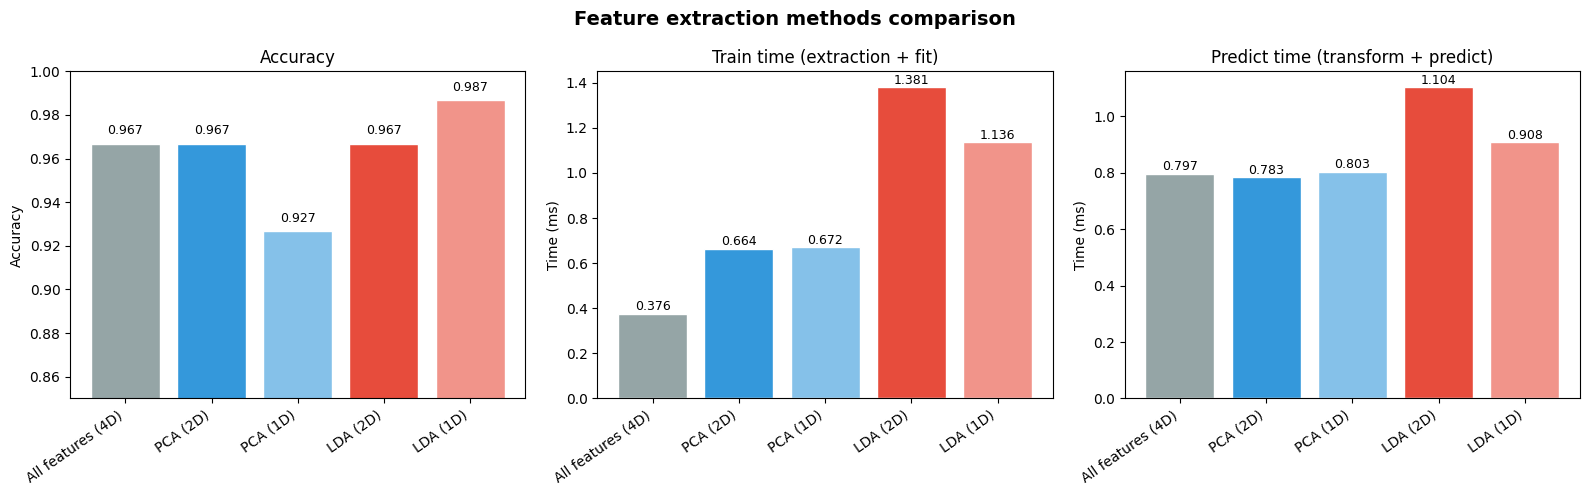

In [22]:
# 三栏柱状图
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

methods = results_df["Method"]
x = np.arange(len(methods))
bar_colors = ["#95a5a6", "#3498db", "#85c1e9", "#e74c3c", "#f1948a"]

# Accuracy
ax = axes[0]
bars = ax.bar(x, results_df["Accuracy"], color=bar_colors, edgecolor="white")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=35, ha="right")
ax.set_ylim(0.85, 1.0)
for bar, val in zip(bars, results_df["Accuracy"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)

# Train time
ax = axes[1]
bars = ax.bar(x, results_df["Train (ms)"], color=bar_colors, edgecolor="white")
ax.set_ylabel("Time (ms)")
ax.set_title("Train time (extraction + fit)")
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=35, ha="right")
for bar, val in zip(bars, results_df["Train (ms)"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)

# Predict time
ax = axes[2]
bars = ax.bar(x, results_df["Predict (ms)"], color=bar_colors, edgecolor="white")
ax.set_ylabel("Time (ms)")
ax.set_title("Predict time (transform + predict)")
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=35, ha="right")
for bar, val in zip(bars, results_df["Predict (ms)"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)

fig.suptitle("Feature extraction methods comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 7.2 结果分析

**准确率：**
- **LDA (2D)** 和 **LDA (1D)** 准确率接近甚至超过全部特征 → 有监督降维能找到最优分类方向
- **PCA (2D)** 准确率略低于全部特征，但仍然很高 → 前 2 个主成分保留了大部分信息
- **PCA (1D)** 准确率下降明显 → 仅靠第一主成分不足以完全区分三个类别

**耗时：**
- 降维后训练和预测时间更短（特征维度降低，KNN 距离计算量减少）
- LDA 训练时间略长（需要计算散度矩阵），但预测时间和 PCA 相当

**结论：**
- 特征提取能在降维的同时保持甚至提升分类性能
- 有监督方法 (LDA) 在分类任务上通常优于无监督方法 (PCA)
- 在实际应用中，降维的计算效率优势在高维数据上更为显著

---
## 8. 总结

### 方法对比总表

| 方法 | 类型 | 维度 | 优化目标 | 优点 | 局限 |
|------|------|------|----------|------|------|
| PCA | 无监督 | 最多 d | 最大化方差 | 无需标签、去相关、降噪 | 不保证类别可分 |
| LDA | 有监督 | 最多 K-1 | 最大化 Fisher 准则 | 直接优化分类目标 | 需要标签、同方差假设 |

### 特征选择 vs 特征提取 总对比

| 维度 | 特征选择 (实验 2) | 特征提取 (实验 3) |
|------|-------------------|-------------------|
| 操作 | 挑选原始特征子集 | 变换为新特征 |
| 新特征含义 | 保留原始物理意义 | 无直接物理意义 |
| 信息利用 | 丢弃未选特征 | 综合利用所有特征 |
| 可解释性 | 高 | 较低 |
| 代表方法 | ANOVA, SFFS | PCA, LDA |

### 核心知识点

| 知识点 | 要点 |
|--------|------|
| PCA 原理 | 中心化 → 协方差矩阵 → 特征值分解 → 投影到最大方差方向 |
| LDA 原理 | 计算 Sw, Sb → 最大化 Fisher 准则 (Sb/Sw) → 投影到最优判别方向 |
| 方差解释比 | 衡量主成分保留了多少原始信息，累计 >= 95% 通常足够 |
| 标准化 | PCA 对特征尺度敏感，量纲不同时必须先标准化 |
| LDA 维度限制 | 最多 K-1 个判别分量（K = 类别数） |
| 无监督 vs 有监督 | PCA 不看标签（适用更广），LDA 利用标签（分类更优） |

### 思考题

1. 如果 Iris 数据集有 **100 个特征**，PCA 和 LDA 分别最多能提取多少个分量？为什么？
2. 对 Iris 数据做 PCA 时，**先标准化和不标准化**结果差异不大，这是为什么？在什么情况下标准化会显著改变结果？
3. PCA 是**无监督**方法，完全不使用标签。那在分类任务中，PCA 为什么仍然有效？它的准确率为什么接近全部特征？
4. 如果两个类别的**协方差矩阵差异很大**（如一个类很紧凑、另一个很分散），LDA 的效果会受影响吗？为什么？可以怎么改进？
5. **特征选择**（实验 2）和**特征提取**（实验 3）各适合什么场景？如果你要处理一个医学诊断数据集（需要医生理解每个特征的含义），你会优先选哪种？为什么？